<!-- STATUS_BLOCK_v1 -->
# flower_visit_validation.ipynb — STATUS

**Pipeline position:** QC tool for `flower_visit_pipeline.ipynb`

**Purpose.**  Visually and quantitatively validate that detected flower
visits are real foraging events (bee approaches, stops, leaves) rather than
tracking artefacts. Plots actual 3D flight trajectories with the camera and
hive marked, builds a spatial heatmap of visit locations, and cross-checks
visits against the exit/return trip structure.

**Inputs:**  `data/multi_day/flower_visits.csv` + raw `data/flight_data/<date>_system_<sys>/flight_tracks.csv`
**Outputs:** figures (inline) only

### WORKS
- 3D trajectory plot of all visits on a chosen day (camera at origin, hive sphere)
- Per-visit zoom panels showing the approach / stationary / departure phases
- All-days spatial heatmap (identifies stable flower patches)
- Duration distribution + trip-structure cross-check

### PENDING
- Manual video cross-check: the ultimate ground truth (match visit timestamps to PATS video)
- Precision/recall once a hand-annotated set exists

---


## How best to validate flower-visit detection

Five complementary lines of evidence, weakest-but-cheapest to
strongest-but-most-effort:

1. **Spatial consistency (free, automatic).** Real flowers occupy fixed
   positions, so genuine visits cluster at the same xyz across many days.
   Artefacts scatter. → Section 3 heatmap.
2. **Trajectory shape (this notebook).** A real visit shows
   approach → deceleration → stationary hold → departure. → Sections 1-2.
3. **Duration plausibility (free).** Bumblebee flower handling time is
   typically 1-30 s. A spike of sub-1 s or implausibly long visits is a
   red flag. → Section 4.
4. **Trip-structure coherence (free).** A real visit should fall *between*
   a hive exit and the next hive return for that period. → Section 5.
5. **Video ground-truth (manual, gold standard).** Pick N detected visits,
   look them up in the PATS video by timestamp, score precision; watch
   random video windows, score recall. Not automated here — but the
   timestamps printed in Section 2 are exactly what you paste into the
   PATS web interface.


In [4]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

DATA_BASE = Path("../../data/flight_data")
HIVE_XYZ  = {900: (-0.040, -0.665, -1.195),
             939: (-0.086, -0.828, -1.045)}
CAMERA_XYZ = (0.0, 0.0, 0.0)   # PATS-C stereo camera is the coordinate origin
HIVE_RADIUS_M = 0.2

# choose the day + system to inspect
VIZ_DATE = "2026-04-22"
VIZ_SYS  = 900

visits = pd.read_csv("data/multi_day/flower_visits.csv")
print(f"flower_visits.csv: {len(visits)} kept visits, {visits.date.nunique()} dates")
day_visits = visits[(visits.date == VIZ_DATE) & (visits.system_id == VIZ_SYS)].copy()
print(f"{VIZ_DATE} sys {VIZ_SYS}: {len(day_visits)} visits")


flower_visits.csv: 1008 kept visits, 29 dates
2026-04-22 sys 900: 26 visits


In [5]:
# Load the raw tracks for the chosen day and index by uid
ft = pd.read_csv(DATA_BASE / f"{VIZ_DATE}_system_{VIZ_SYS}/flight_tracks.csv",
                 usecols=["detection_uid", "elapsed", "pos_valid_insect",
                          "sposX_insect", "sposY_insect", "sposZ_insect"])
ft = ft[ft.pos_valid_insect == 1].sort_values("elapsed")
tracks_by_uid = dict(tuple(ft.groupby("detection_uid")))
print(f"loaded {len(ft):,} valid frames in {ft.detection_uid.nunique()} tracks")

def visit_uids(row):
    return [int(u) for u in str(row["uids"]).split(";") if u]


loaded 164,315 valid frames in 846 tracks


## 1. All visits on the chosen day — 3D trajectories

Each detected visit's full track(s) plotted in 3D. The **stationary
segment** (the actual flower visit) is drawn thick/dark; the approach and
departure are thin/light. Camera (black square) at the origin, hive (red
wireframe sphere) at its measured position.


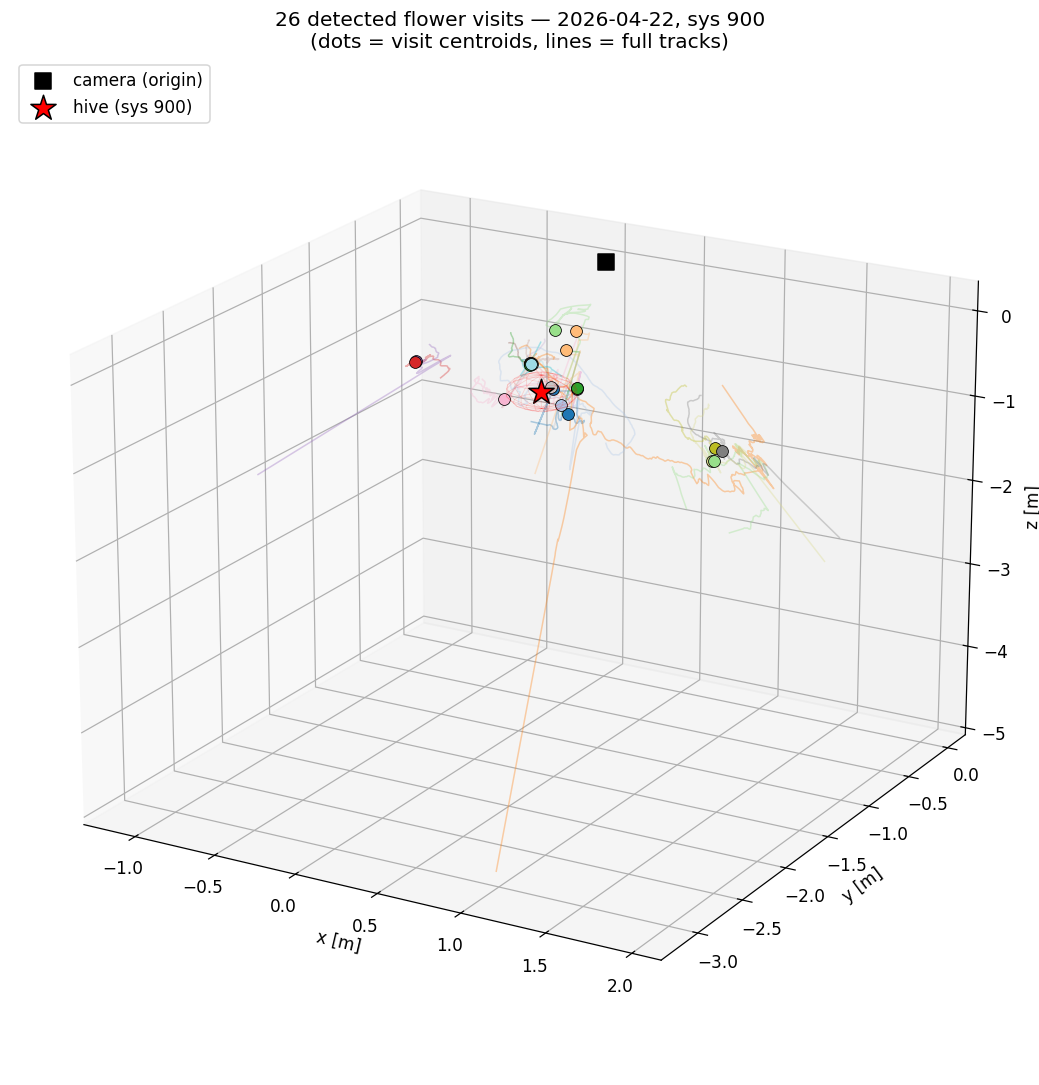

In [6]:
def draw_sphere(ax, center, radius, color="red", alpha=0.15):
    u, v = np.mgrid[0:2*np.pi:16j, 0:np.pi:8j]
    x = center[0] + radius*np.cos(u)*np.sin(v)
    y = center[1] + radius*np.sin(u)*np.sin(v)
    z = center[2] + radius*np.cos(v)
    ax.plot_wireframe(x, y, z, color=color, alpha=alpha, linewidth=0.5)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")
hx, hy, hz = HIVE_XYZ[VIZ_SYS]
cmap = plt.get_cmap("tab20")

for i, (_, v) in enumerate(day_visits.iterrows()):
    col = cmap(i % 20)
    for uid in visit_uids(v):
        trk = tracks_by_uid.get(uid)
        if trk is None: continue
        ax.plot(trk.sposX_insect, trk.sposY_insect, trk.sposZ_insect,
                color=col, alpha=0.35, linewidth=1)
    # stationary segment marker = the visit centroid
    ax.scatter([v.x], [v.y], [v.z], color=col, s=60, edgecolor="black",
               linewidth=0.5, zorder=6)

# camera + hive
ax.scatter(*CAMERA_XYZ, marker="s", s=120, c="black", label="camera (origin)")
draw_sphere(ax, (hx, hy, hz), HIVE_RADIUS_M, color="red")
ax.scatter([hx],[hy],[hz], marker="*", s=300, c="red", edgecolor="black", label=f"hive (sys {VIZ_SYS})")

ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.set_title(f"{len(day_visits)} detected flower visits — {VIZ_DATE}, sys {VIZ_SYS}\n"
             f"(dots = visit centroids, lines = full tracks)")
ax.legend(loc="upper left")
ax.view_init(elev=20, azim=-60)
plt.tight_layout(); plt.show()


## 2. Per-visit zoom panels

The longest visits of the day, each in its own 3D panel zoomed to the
track. Colour encodes time-within-track (dark = start, bright = end), so
you can see the bee fly in, slow to a stop (points bunch up), and leave.
The printed timestamps are paste-ready for the PATS video lookup.


visit  wall_start   dur(s)   source  uids
    0    04:22:57    26.65    cross  1489935;1491210
    1    04:50:48    19.12   merged  1488890;1488919
    2    04:39:04     7.43    cross  1486178;1483410
    3    04:53:28     6.23    cross  1481774;1481781
    4    04:40:54     5.02   within  1483485
    5    04:56:48     4.22    cross  1486869;1491567


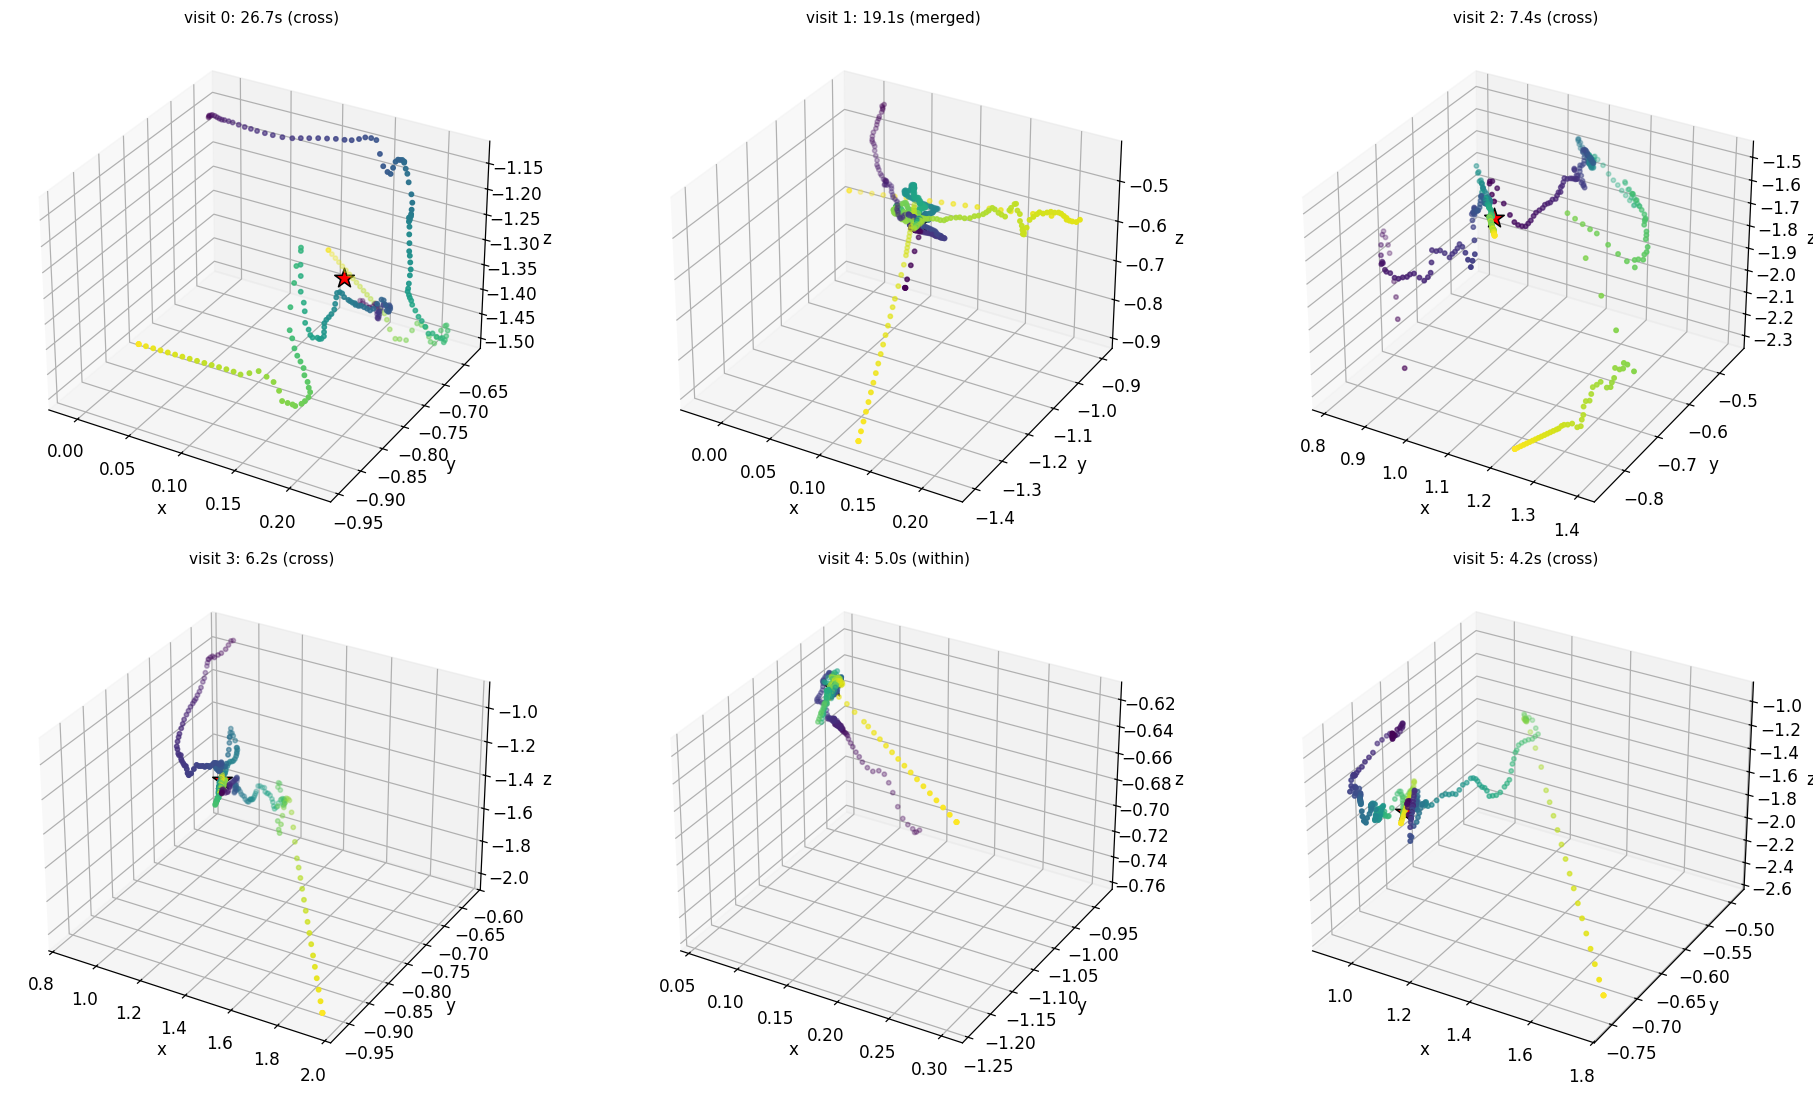

In [7]:
top = day_visits.sort_values("duration_s", ascending=False).head(6).reset_index(drop=True)
n = len(top)
ncol = 3; nrow = int(np.ceil(n/ncol))
fig = plt.figure(figsize=(6*ncol, 5*nrow))

# day origin timestamp for wall-clock conversion
import datetime
det = pd.read_csv(DATA_BASE / f"{VIZ_DATE}_system_{VIZ_SYS}/detections.csv")
t_origin = pd.to_datetime(det["start_datetime"]).min()

print(f"{'visit':>5s}  {'wall_start':>10s}  {'dur(s)':>7s}  {'source':>7s}  uids")
for i, (_, v) in enumerate(top.iterrows()):
    ax = fig.add_subplot(nrow, ncol, i+1, projection="3d")
    for uid in visit_uids(v):
        trk = tracks_by_uid.get(uid)
        if trk is None: continue
        c = np.linspace(0, 1, len(trk))
        ax.scatter(trk.sposX_insect, trk.sposY_insect, trk.sposZ_insect,
                   c=c, cmap="viridis", s=8)
    ax.scatter([v.x],[v.y],[v.z], marker="*", s=180, c="red",
               edgecolor="black", zorder=6)
    ax.set_title(f"visit {i}: {v.duration_s:.1f}s ({v.source})", fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    wall = (t_origin + pd.to_timedelta(v.t_start_s, unit="s")).strftime("%H:%M:%S")
    print(f"{i:>5d}  {wall:>10s}  {v.duration_s:7.2f}  {v.source:>7s}  {v.uids}")
plt.tight_layout(); plt.show()


## 3. All-days spatial heatmap — where are the flowers?

Pooling visits from *every* day, a 2D density of visit positions. Stable
hot-spots = real flowers/feeders; diffuse smear = artefacts. The hive and
camera are marked. This is the strongest *automatic* validation: real
flower locations recur across the whole experiment.


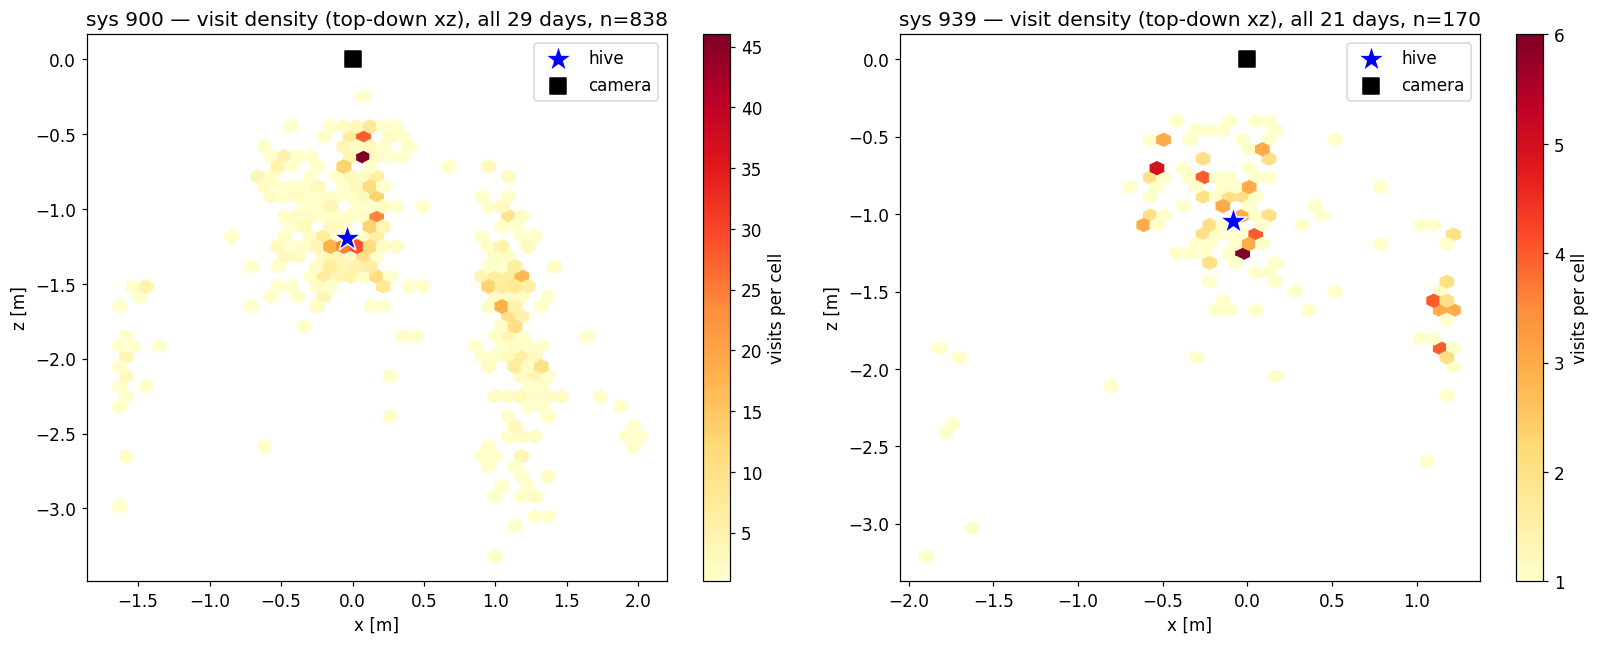

Dominant visit clusters (sys 900), by rounded (x,z) 20-cm grid:
  gx   gz  n
-0.0 -0.6 89
-0.0 -1.2 59
 1.0 -1.6 44
 0.2 -1.0 42
-0.2 -1.2 39
 0.2 -1.2 38
 1.2 -1.4 30
-0.2 -1.4 25


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, sid in zip(axes, [900, 939]):
    sub = visits[visits.system_id == sid]
    hx, hy, hz = HIVE_XYZ[sid]
    hb = ax.hexbin(sub.x, sub.z, gridsize=40, cmap="YlOrRd", mincnt=1)
    ax.scatter([hx],[hz], marker="*", s=350, c="blue", edgecolor="white",
               linewidth=1, label="hive", zorder=6)
    ax.scatter(CAMERA_XYZ[0], CAMERA_XYZ[2], marker="s", s=120, c="black",
               label="camera", zorder=6)
    ax.set_xlabel("x [m]"); ax.set_ylabel("z [m]")
    ax.set_title(f"sys {sid} — visit density (top-down xz), all {sub.date.nunique()} days, n={len(sub)}")
    ax.legend()
    plt.colorbar(hb, ax=ax, label="visits per cell")
plt.tight_layout(); plt.show()

# Report the dominant flower clusters
print("Dominant visit clusters (sys 900), by rounded (x,z) 20-cm grid:")
s900 = visits[visits.system_id==900].copy()
s900["gx"] = (s900.x/0.2).round()*0.2
s900["gz"] = (s900.z/0.2).round()*0.2
top_cells = (s900.groupby(["gx","gz"]).size().reset_index(name="n")
                  .sort_values("n", ascending=False).head(8))
print(top_cells.to_string(index=False))


## 4. Visit-duration distribution

Bumblebee flower handling time is typically a few seconds to ~30 s.
A clean detector should produce a unimodal, right-skewed distribution in
that range. A spike at the `MIN_VISIT_S` floor (1 s) suggests many
borderline detections; a fat tail beyond ~60 s suggests merged/!=visit
events.


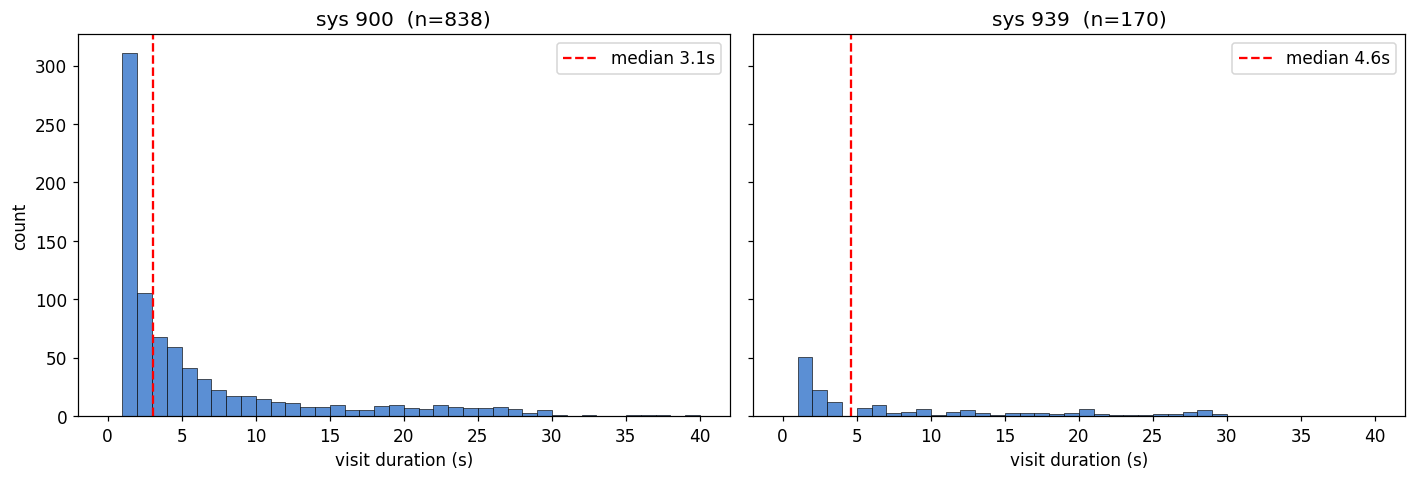

Duration stats:
  sys 900: median=3.1s  IQR=[1.5,7.6]  <2s: 37%  >30s: 1%
  sys 939: median=4.6s  IQR=[1.5,13.9]  <2s: 30%  >30s: 1%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, sid in zip(axes, [900, 939]):
    s = visits.loc[visits.system_id==sid, "duration_s"]
    ax.hist(s, bins=np.linspace(0, 40, 41), color="#5B8FD4", edgecolor="black", linewidth=0.4)
    ax.axvline(s.median(), color="red", linestyle="--", label=f"median {s.median():.1f}s")
    ax.set_xlabel("visit duration (s)"); ax.set_title(f"sys {sid}  (n={len(s)})")
    ax.legend()
axes[0].set_ylabel("count")
plt.tight_layout(); plt.show()

print("Duration stats:")
for sid in [900, 939]:
    s = visits.loc[visits.system_id==sid, "duration_s"]
    pct_under_2 = (s < 2).mean()*100
    pct_over_30 = (s > 30).mean()*100
    print(f"  sys {sid}: median={s.median():.1f}s  IQR=[{s.quantile(.25):.1f},{s.quantile(.75):.1f}]  "
          f"<2s: {pct_under_2:.0f}%  >30s: {pct_over_30:.0f}%")


## 5. Trip-structure cross-check

A real flower visit should occur **between** a hive exit and the next hive
return. We load the per-track indicators (v3 exits) and the hive-return
timestamps, then for each visit on the chosen day check whether it falls
inside an open foraging trip (after an exit, before the matched return).

A high fraction inside trips = visits are coherent with foraging behaviour.
A low fraction = many visits happen when no bee is supposed to be out
(suspicious).


In [10]:
pti = pd.read_csv("data/multi_day/per_track_indicators.csv", parse_dates=["ts"])
day_pti = pti[(pti.date == VIZ_DATE) & (pti.system_id == VIZ_SYS)].copy()

# elapsed seconds of each exit/return relative to day origin
day_pti["elapsed_s"] = (day_pti["ts"] - t_origin).dt.total_seconds()
exit_t   = sorted(day_pti.loc[day_pti.hive_exit_v3, "elapsed_s"].dropna().tolist())
return_t = sorted(day_pti.loc[day_pti.hive_return,  "elapsed_s"].dropna().tolist())

def in_open_trip(t):
    # is there an exit before t with a return after t (some bee plausibly out)?
    last_exit = max([e for e in exit_t if e <= t], default=None)
    if last_exit is None: return False
    next_return = min([r for r in return_t if r >= t], default=None)
    return next_return is not None

if len(day_visits):
    inside = day_visits["t_start_s"].apply(in_open_trip)
    print(f"{VIZ_DATE} sys {VIZ_SYS}: {inside.sum()}/{len(day_visits)} "
          f"visits ({100*inside.mean():.0f}%) fall inside an open foraging trip "
          f"(exit before, return after)")
    print(f"  ({len(exit_t)} v3 exits, {len(return_t)} returns logged that day)")
else:
    print("no visits on the chosen day")


2026-04-22 sys 900: 0/26 visits (0%) fall inside an open foraging trip (exit before, return after)
  (110 v3 exits, 139 returns logged that day)


## 6. Recommendations for improving the detector

Based on what these plots typically reveal:

1. **The x≈1.1 m cluster is a real flower patch** (it recurs every day with
   11 cm positional spread). Consider naming/whitelisting known flower
   locations and treating visits *at* those locations as higher-confidence.

2. **Symmetrical exit/return logic** (the v3-restructure idea) will help:
   right now returns outnumber exits because the return test is naive
   (within 0.1 m over last 10 frames) while the exit test is strict
   (backward velocity extrapolation + speed gate). Making the return logic
   forward-extrapolate the *last* 10 frames' velocity into the hive sphere,
   with the same < 0.5 m/s landing-speed gate, would balance the counts and
   reduce fly-by false positives.

3. **Spike healing, not track deletion.** The raw data has 1-2 frame
   teleportations (>7 m/s). Nullify just those frames and linearly
   interpolate — don't drop the whole track. Because the visit detector
   already runs on *smoothed* positions over a 1-second window, single-frame
   spikes are mostly averaged out, so healing them changes results only at
   the margin and does **not** bias the visit count.

4. **Two-zone foraging is the headline.** Bees use the hive zone (x≈0) and
   the patch zone (x≈1.1). An ON-vs-OFF analysis could test whether the
   *split* between zones changes under exposure (e.g. do bees abandon the
   far patch under 5G?).
